imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 12

configuração do arquivo

In [2]:
# Caminho do arquivo ECG
# Troque para o seu arquivo real
file_path = "../data/processed/cnn_X.npy"

# Frequência de amostragem estimada
fs = 200  # Hz

carregar dados

In [3]:
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Arquivo não encontrado: {file_path}")

ecg_data = np.load(file_path)

print("Tipo:", type(ecg_data))
print("Shape:", ecg_data.shape)
print("Dtype:", ecg_data.dtype)

Tipo: <class 'numpy.ndarray'>
Shape: (23005, 3600)
Dtype: float32


inspecionar estrutura

In [4]:
# Se for matriz, vamos pegar um exemplo
if ecg_data.ndim == 1:
    ecg_signal = ecg_data
elif ecg_data.ndim == 2:
    ecg_signal = ecg_data[0]   # pega o primeiro sinal
elif ecg_data.ndim == 3:
    ecg_signal = ecg_data[0, :, 0]  # caso tenha formato tipo [amostras, tempo, canal]
else:
    raise ValueError(f"Formato não suportado: {ecg_data.shape}")

print("Shape do sinal selecionado:", ecg_signal.shape)
print("Primeiros 10 valores:", ecg_signal[:10])

Shape do sinal selecionado: (3600,)
Primeiros 10 valores: [1.0276057 1.0276057 1.0276057 1.0276057 1.0276057 1.0276057 1.0276057
 1.0276057 1.1744717 1.0863521]


vetor de tempo

In [5]:
t = np.arange(len(ecg_signal)) / fs
duration = len(ecg_signal) / fs

print(f"Número de amostras: {len(ecg_signal)}")
print(f"Duração estimada: {duration:.2f} s")

Número de amostras: 3600
Duração estimada: 18.00 s


estatísticas básicas

In [6]:
print("Estatísticas do sinal ECG")
print(f"Mínimo:      {np.min(ecg_signal):.4f}")
print(f"Máximo:      {np.max(ecg_signal):.4f}")
print(f"Média:       {np.mean(ecg_signal):.4f}")
print(f"Desvio pad.: {np.std(ecg_signal):.4f}")
print(f"Mediana:     {np.median(ecg_signal):.4f}")

Estatísticas do sinal ECG
Mínimo:      -1.9097
Máximo:      7.5191
Média:       -0.0000
Desvio pad.: 1.0000
Mediana:     -0.1473


plot do sinal completo

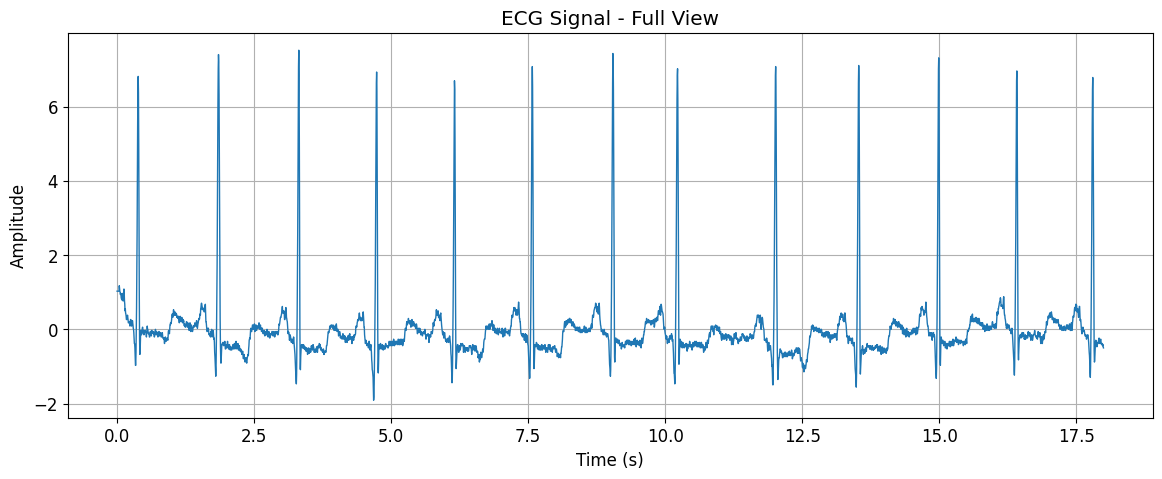

In [7]:
plt.figure()
plt.plot(t, ecg_signal, linewidth=1)
plt.title("ECG Signal - Full View")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

zoom do início do sinal

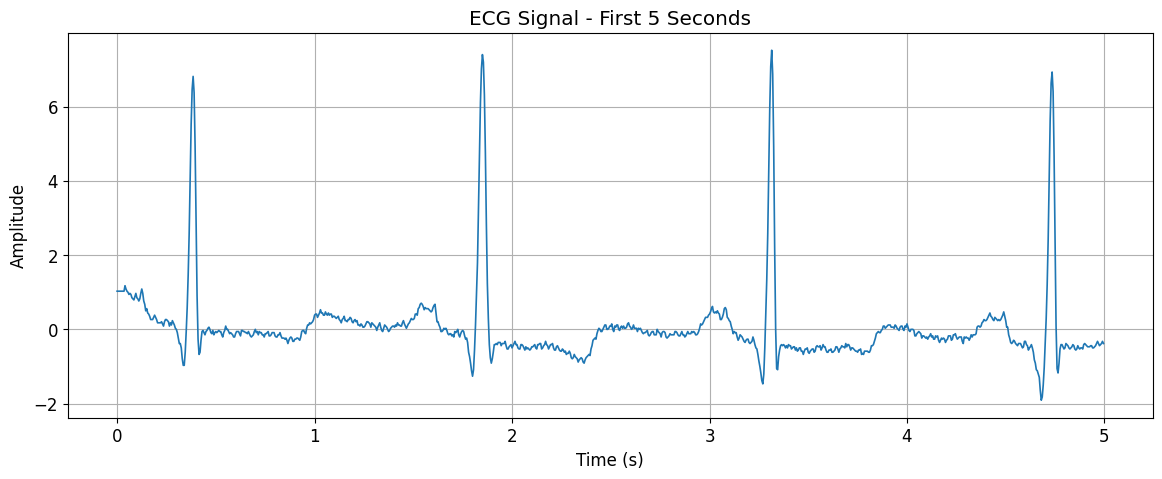

In [8]:
zoom_seconds = 5
zoom_samples = int(zoom_seconds * fs)

plt.figure()
plt.plot(t[:zoom_samples], ecg_signal[:zoom_samples], linewidth=1.2)
plt.title(f"ECG Signal - First {zoom_seconds} Seconds")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

histograma

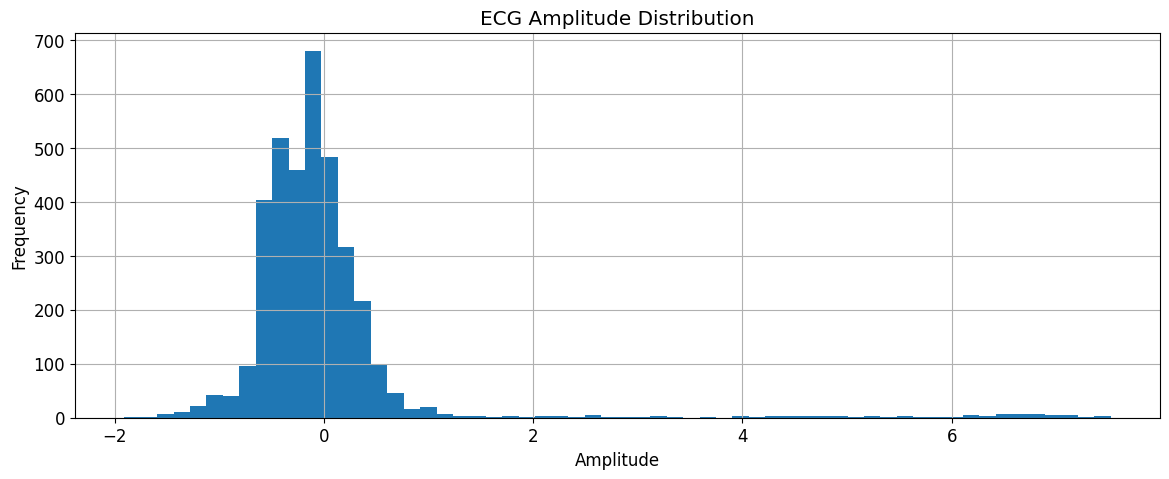

In [9]:
plt.figure()
plt.hist(ecg_signal, bins=60)
plt.title("ECG Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

normalização

In [10]:
ecg_norm = (ecg_signal - np.mean(ecg_signal)) / np.std(ecg_signal)

print("Sinal normalizado:")
print(f"Média: {np.mean(ecg_norm):.4f}")
print(f"Desvio padrão: {np.std(ecg_norm):.4f}")

Sinal normalizado:
Média: -0.0000
Desvio padrão: 1.0000


plot do sinal normalizado

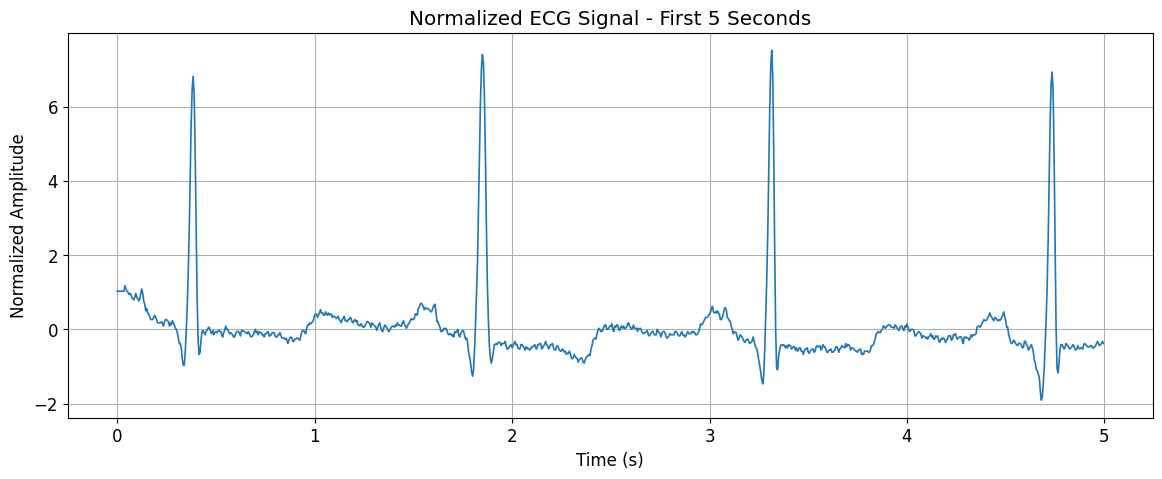

In [11]:
plt.figure()
plt.plot(t[:zoom_samples], ecg_norm[:zoom_samples], linewidth=1.2)
plt.title(f"Normalized ECG Signal - First {zoom_seconds} Seconds")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.show()

FFT / análise espectral

In [12]:
n = len(ecg_signal)
freqs = np.fft.rfftfreq(n, d=1/fs)
fft_vals = np.fft.rfft(ecg_signal)
fft_mag = np.abs(fft_vals)

plot do espectro

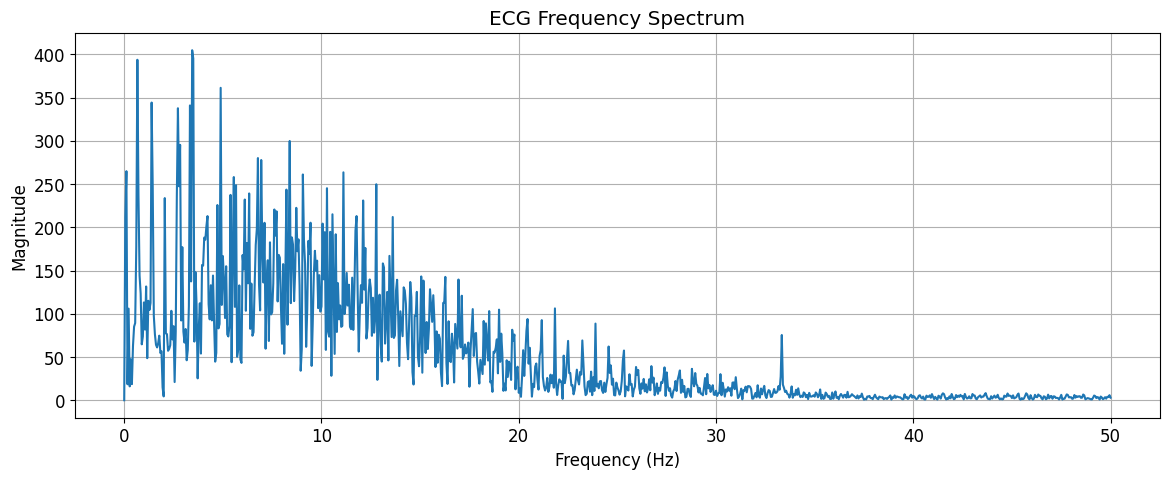

In [13]:
max_freq_to_show = 50  # Hz

mask = freqs <= max_freq_to_show

plt.figure()
plt.plot(freqs[mask], fft_mag[mask])
plt.title("ECG Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

resumo automático

In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Number of samples",
        "Duration (s)",
        "Minimum",
        "Maximum",
        "Mean",
        "Std",
        "Median"
    ],
    "Value": [
        len(ecg_signal),
        duration,
        np.min(ecg_signal),
        np.max(ecg_signal),
        np.mean(ecg_signal),
        np.std(ecg_signal),
        np.median(ecg_signal)
    ]
})

summary

,Metric,Value
0,Number of samples,3.600000e+03
1,Duration (s),1.800000e+01
2,Minimum,-1.909716e+00
3,Maximum,7.519087e+00
4,Mean,-8.053249e-08
5,Std,9.999999e-01
6,Median,-1.473231e-01


conclusão simples

In [15]:
print("Notebook 01 - ECG Signal Analysis completed successfully.")
print("This notebook provides:")
print("- Basic ECG loading")
print("- Statistical analysis")
print("- Full signal visualization")
print("- Zoomed signal visualization")
print("- Amplitude histogram")
print("- Frequency-domain analysis")

Notebook 01 - ECG Signal Analysis completed successfully.
This notebook provides:
- Basic ECG loading
- Statistical analysis
- Full signal visualization
- Zoomed signal visualization
- Amplitude histogram
- Frequency-domain analysis
